In [ ]:
%pip install puremacro


# Nowcasting del PIB en Frecuencia Mixta — Seguimiento de la Economía en Tiempo Real

**¿Cómo pueden los bancos centrales y las autoridades fiscales estimar el crecimiento del PIB del trimestre en curso antes de las publicaciones estadísticas oficiales?**

Los indicadores macroeconómicos se publican con frecuencias más altas (mensual o semanal) y con rezagos asíncronos, generando **bordes irregulares (ragged edges)** al final de la muestra.

Domenico Giannone, Lucrezia Reichlin y David Small (2008, *Journal of Monetary Economics*) introdujeron el **Modelo de Factores Dinámicos (DFM)** con datos faltantes.

En este tutorial interactivo, estimamos el nowcast del PIB y descomponemos el impacto de las noticias económicas mediante `puremacro.nowcast.nowcast_gdp`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.nowcast import nowcast_gdp

## 1. Simulación de Panel Macroeconómico Asíncrono

In [2]:
rng = np.random.default_rng(42)
n_months = 72
dates_m = pd.date_range("2018-01-01", periods=n_months, freq="MS")

F_true = np.zeros((n_months, 2))
for t in range(1, n_months):
    F_true[t, 0] = 0.85 * F_true[t-1, 0] + rng.normal(scale=0.8)
    F_true[t, 1] = 0.60 * F_true[t-1, 1] + rng.normal(scale=0.5)

var_names = [
    "Producción Industrial", "Empleo Formal", "Ventas Minoristas",
    "Inicios de Vivienda", "Utilización de Capacidad", "PMI Manufactura",
    "Inflación Subyacente", "Ingreso Personal Real", "Pedidos de Exportación", "Confianza del Consumidor"
]
N = len(var_names)
X = np.zeros((n_months, N))
for i in range(N):
    load = rng.uniform(0.4, 1.6, size=2)
    X[:, i] = F_true @ load + rng.normal(scale=0.4, size=n_months)

df_X = pd.DataFrame(X, index=dates_m, columns=var_names)
df_X.iloc[-1, [3, 4, 8, 9]] = np.nan

dates_q = pd.date_range("2018-01-01", periods=n_months // 3, freq="QS")
F_q = df_X.resample("QE").mean().to_numpy().mean(axis=1)[:len(dates_q)]
gdp = 2.2 + 1.4 * F_q + rng.normal(scale=0.3, size=len(dates_q))
s_gdp = pd.Series(gdp, index=dates_q.to_period("Q").astype(str), name="PIB")

## 2. Estimación del Nowcast DFM y Descomposición de Noticias

In [3]:
res = nowcast_gdp(df_X, s_gdp, n_factors=2)
print(res.summary())

Dynamic Factor Model GDP Nowcasting (Giannone, Reichlin & Small 2008)
Target Quarter                  : 2023Q4
GDP Growth Nowcast              : 4.41 (units of quarterly_gdp)
Quarterly Bridge Regression R²  : 0.9809
Latent Monthly Factors (K)      : 2
Target-quarter months forecast  : 0 (factor VAR)
--------------------------------------------------------------------------
Latest News & Contribution Decomposition:
  Producción Industrial  | Surprise:  +0.12 | Impact: +0.009
  Empleo Formal          | Surprise:  +0.48 | Impact: +0.014
  Ventas Minoristas      | Surprise:  -0.52 | Impact: -0.023
  PMI Manufactura        | Surprise:  +0.23 | Impact: +0.015
  Inflación Subyacente   | Surprise:  +0.02 | Impact: +0.001
  Ingreso Personal Real  | Surprise:  -0.46 | Impact: -0.017


## 3. Factores Mensuales Latentes y Cargas Factoriales

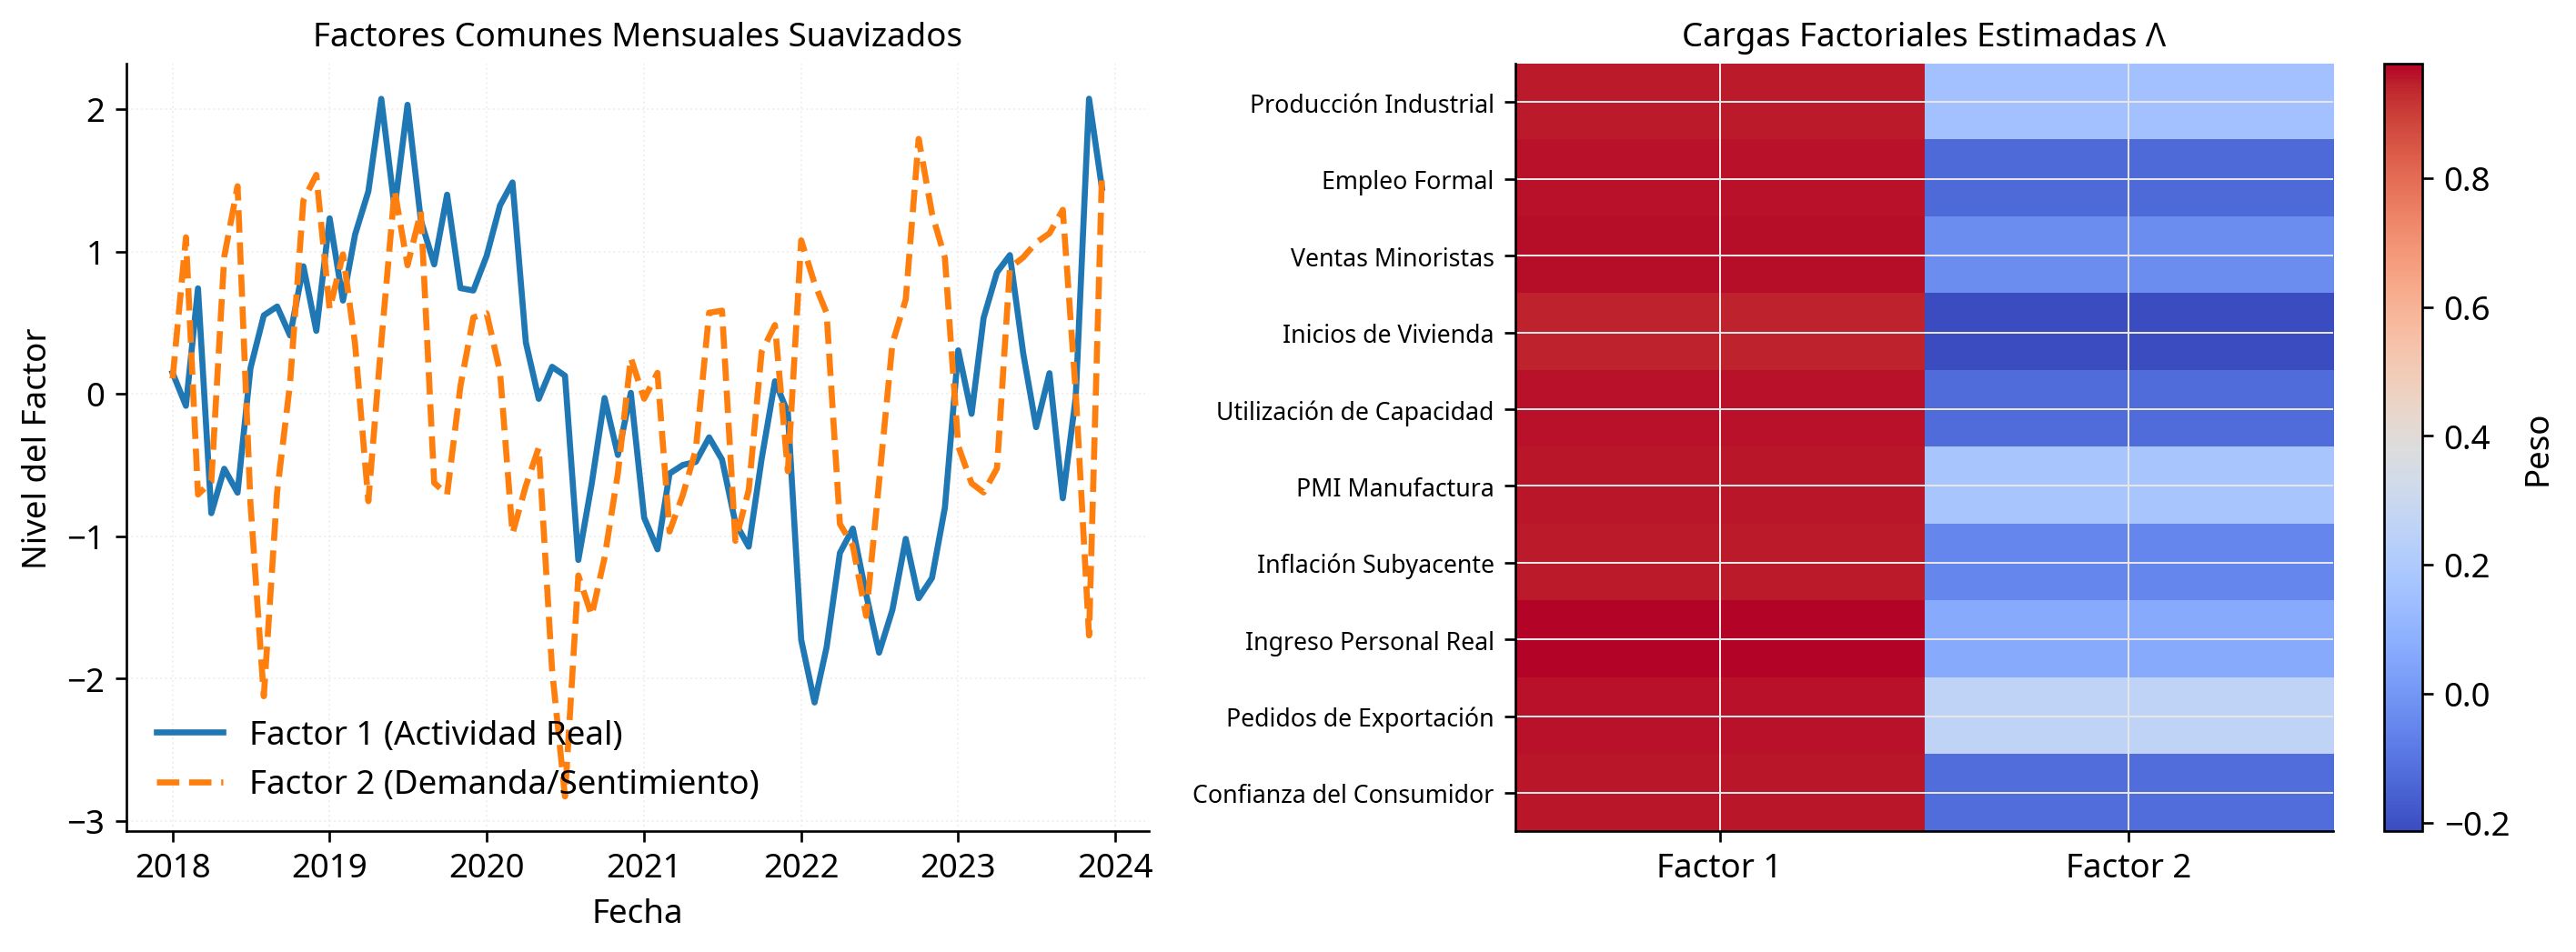

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(df_X.index, res.factors["Factor_1"], color="#1f77b4", lw=2, label="Factor 1 (Actividad Real)")
ax1.plot(df_X.index, res.factors["Factor_2"], color="#ff7f0e", lw=2, linestyle="--", label="Factor 2 (Demanda/Sentimiento)")
ax1.set_title("Factores Comunes Mensuales Suavizados", fontsize=11, fontweight="bold")
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Nivel del Factor")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

im = ax2.imshow(res.loadings.to_numpy(), cmap="coolwarm", aspect="auto")
ax2.set_yticks(range(N))
ax2.set_yticklabels(var_names, fontsize=8)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Factor 1", "Factor 2"])
ax2.set_title("Cargas Factoriales Estimadas Λ", fontsize=11, fontweight="bold")
fig.colorbar(im, ax=ax2, label="Peso")

plt.tight_layout()
plt.show()

## 4. Impacto de las Noticias en la Revisión del Nowcast

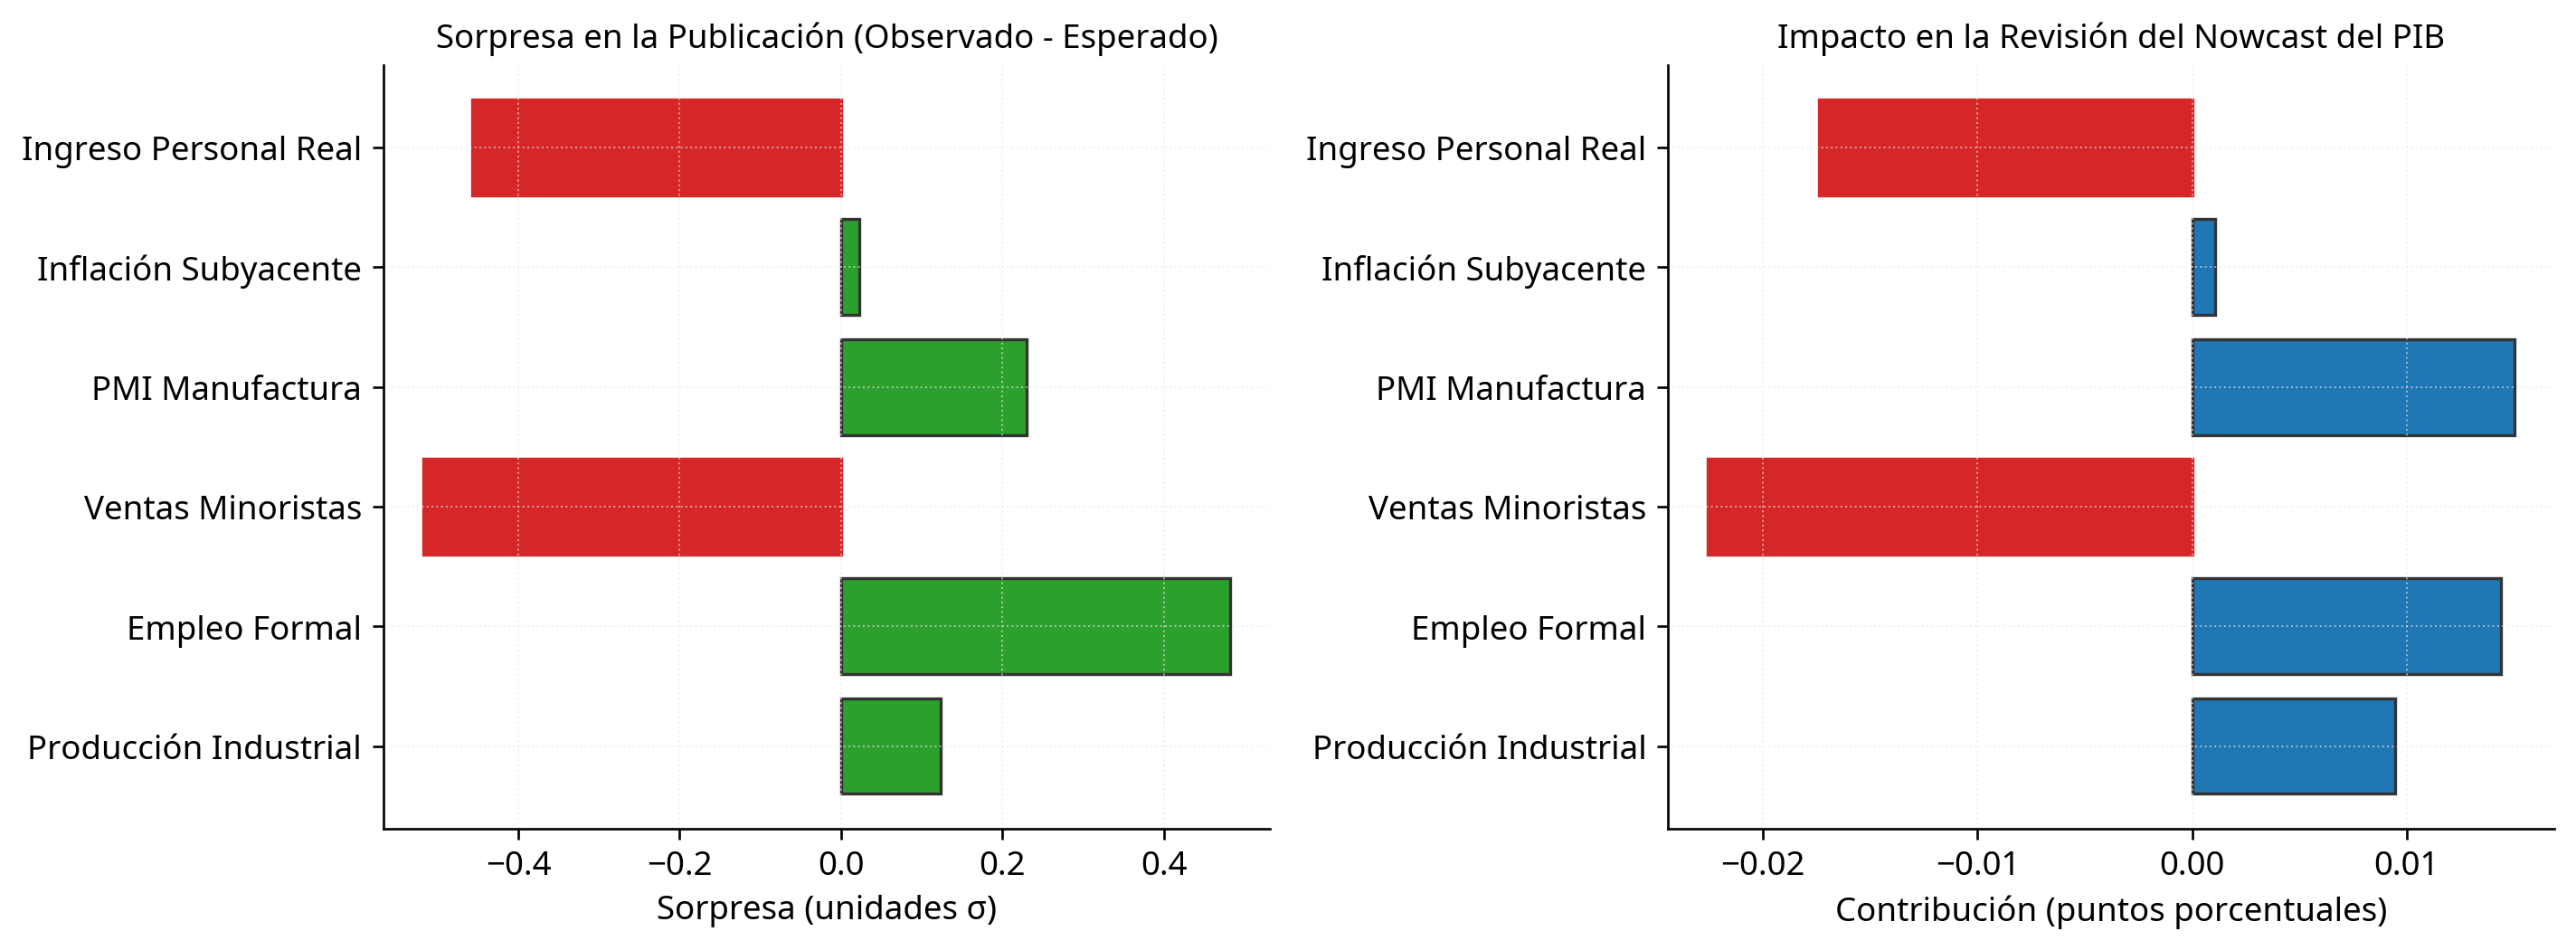

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

if not res.news_decomposition.empty:
    bars1 = ax1.barh(res.news_decomposition["series"], res.news_decomposition["surprise"], color="#2ca02c", edgecolor="#333")
    for b in bars1:
        if b.get_width() < 0:
            b.set_color("#d62728")
    ax1.set_title("Sorpresa en la Publicación (Observado - Esperado)", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Sorpresa (unidades σ)")
    ax1.grid(True, linestyle=":", alpha=0.6)

    bars2 = ax2.barh(res.news_decomposition["series"], res.news_decomposition["contribution"], color="#1f77b4", edgecolor="#333")
    for b in bars2:
        if b.get_width() < 0:
            b.set_color("#d62728")
    ax2.set_title("Impacto en la Revisión del Nowcast del PIB", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Contribución (puntos porcentuales)")
    ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()